In [4]:
#Setting 
root_dir = "D:\\Rodrigo"

# Needed Stuff

## Requirements Python 3.8.16

tqdm
pandas
seaborn
matplotlib
numpy
scikit-learn
parmap
scipy
opencv-python
networkx
suite2p
utils.calcium

## Imports

In [1]:
# imports
# Statistics
import seaborn as sns
import pandas as pd
import numpy as np

# Plotting
import matplotlib as mlp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Regular Expression searching
import re

# Suite2p for TIFF file analysis
from suite2p.run_s2p import run_s2p, default_ops

# Used for Popups
import tkinter as tk

import nest_asyncio

# 
from tqdm import tqdm
import os
import sys
import scipy

# Mesc file analysis
import h5py
from tifffile import tifffile, imread
import pathlib

#
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# add root directory to be able to import packages
# todo: make all packages installable so they can be called/imported by environment
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

from utils.calcium import calcium

C:\Users\mauls\AppData\Local\Temp\ipykernel_5104\3951283963.py:36: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


## Helper functions and Classes

In [2]:
# Helper functions directories, Popups, file search
def load_all(root_dir, animal_ids=["all"], generate=False, regenerate=False, units="single", delete=False):
    """
    Loads animal data from the specified root directory for the given animal IDs.

    Parameters:
    - root_dir (string): The root directory path where the animal data is stored.
    - animal_ids (list, optional): A list of animal IDs to load. Default is ["all"].
    - generate (bool, optional): If True, generates new session data. Default is False.
    - regenerate (bool, optional): If True, regenerates existing session data. Default is False.
    - units (string, optional): Specifies the units. Default is "single".
    - delete (bool, optional): If True, deletes session data. Default is False.

    Returns:
    - animals_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.
    """
    animal_ids = get_directories(root_dir)
    animals_dict = {}

    # Search for animal_ids
    for animal_id in animal_ids:
        if animal_id in animal_ids or animal_ids[0] == "all":
            sessions_path = os.path.join(root_dir, animal_id)
            sessions = get_directories(sessions_path)
            yaml_file_name = os.path.join(root_dir, animal_id, f"{animal_id}.yaml")
            animal = Animal(yaml_file_name)
            # Search for 2P Sessions
            for session in sessions:
                animal.get_session_data(session, generate=generate, regenerate=regenerate, units=units, delete=delete)
            animals_dict[animal_id] = animal
    return animals_dict

def filter_animals(animal_dict, filters = []):
    """
    Filters the animal dictionary based on the specified filters.

    Parameters:
    - animal_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.
    - filters (list, optional): A list of filters to apply. Default is an empty list.

    Returns:
    - filtered_animal_dict (dict): A dictionary containing filtered animal IDs as keys and corresponding Animal objects as values.
    """
    filtered_animal_dict = animal_dict
    for filter in filters:
        tmp_animal_dict = {}
        for animal_id, animal in filtered_animal_dict.items():
            if filter == animal_id:
                tmp_animal_dict[animal_id] = animal
                continue
            if animal.year == filter: # cohort_year
                tmp_animal_dict[animal_id] = animal
                continue
            if filter == "male" or filter == "female":
                tmp_animal_dict[animal_id] = animal
                continue
        filtered_animal_dict = tmp_animal_dict
    return filtered_animal_dict

def get_age_range(animal_dict):
    """
    Retrieves the minimum and maximum age range from the given animal dictionary.

    Parameters:
    - animal_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.

    Returns:
    - min_age (int): The minimum age value found among all animals.
    - max_age (int): The maximum age value found among all animals.
    """
    ages_list = []
    min_age = float('inf')
    max_age = 0
    for animal_id, animal in animal_dict.items():
        ages_list.append(animal.pdays)
        min_age = min(animal.pdays) if min(animal.pdays) < min_age else min_age
        max_age = max(animal.pdays) if max(animal.pdays) > max_age else max_age
    unique_sorted_ages = np.unique(ages_list)
    unique_sorted_ages.sort() 
    return unique_sorted_ages, min_age, max_age

### Popups
def yes_no_q(Question):
    """
    Displays a popup window with a yes/no question and returns the user's answer.

    Args:
        Question (str): The question to display in the popup window.

    Returns:
        bool: True if the user clicked "Yes", False if the user clicked "No".
    """
    def on_button_click(button_text):
        global result
        result = button_text
        root.destroy()

    root = tk.Tk()

    label = tk.Label(root, text=Question)
    label.pack()

    button1 = tk.Button(root, text="Yes", command=lambda: on_button_click("Yes"))
    button1.pack()

    button2 = tk.Button(root, text="No", command=lambda: on_button_click("No"))
    button2.pack()

    root.mainloop()

    return True if result=="Yes" else False

#### directory, file search
def dir_exist_create(directory):
    """
    Checks if a directory exists and creates it if it doesn't.

    Parameters:
    dir (str): Path of the directory to check and create.

    Returns:
    None
    """
    # Check if the directory exists
    if not os.path.exists(directory):
        # Create the directory
        os.makedirs(directory)

def del_present_file(directory):
    """
    Deletes a file if it exists.

    Parameters:
    file_location (str): Path of the file to delete.

    Returns:
    None
    """
    # check if the file exists
    if os.path.exists(directory):
        # delete the file
        os.remove(directory)

def get_directories(directory):
    """
    Returns a list of directories in the specified folder path.

    Args:
        folder_path (str): The path of the folder to get the directories from.

    Returns:
        list: A list of directory names.
    """
    # Get a list of directories in the specified folder
    # Filter the list to include only directories (excluding the "figures" directory)
    directories = [name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name)) and name!="figures"]
    return directories

def get_files(directory, ending="all"):
    """
    This function returns a list of files in a given directory. 
    If an ending is specified, it returns only the files that end with the specified ending.
    
    :param directory: The directory to search for files.
    :type directory: str
    :param ending: The file ending to filter by. Default value is "all", which returns all files.
    :type ending: str
    :return: A list of files in the given directory. If an ending is specified, only files that end with the specified ending are returned.
    :rtype: list
    """
    files_list = [name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))]
    #if len(files_list) == 0:
    #    print(f"No files found in {directory}")
    if ending != "all":
        files_list_with_ending = []
        for file in files_list:
            if file.endswith(ending):
                files_list_with_ending.append(file)
        return files_list_with_ending
    return files_list

def search_file(directory, filename):
    """
    This function searches for a file with a given filename within a specified directory and its subdirectories.

    :param directory: The directory in which to search for the file.
    :type directory: str
    :param filename: The name of the file to search for.
    :type filename: str
    :return: The full path of the file if found, otherwise returns the string "Not found".
    :rtype: str
    """
    for root, dirs, files in os.walk(directory):
        if filename in files:
            return os.path.join(root, filename)
    return None

In [39]:
class Analyzer:
    """
    Class for analyzing animal datasets.

    Attributes:
        mean_threshold (float): Threshold value for mean correlation.
        std_threshold (float): Threshold value for standard deviation of correlation.
        animals (dict): Dictionary of animals and their corresponding sessions.

    Methods:
        __init__(self, animals={}): Initializes an Analyzer object.
        volition(self): Placeholder method for analyzing volition.
        good_mean_std(self, mean, std): Checks if the mean and standard deviation meet the good criteria.
        evaluate_datasets_count(self, animals=None): Evaluates the count of good and bad datasets.
    """

    mean_threshold = 0.1
    std_threshold = 0.15

    def __init__(self, animals={}):
        """
        Initializes an Analyzer object.

        Args:
            animals (dict, optional): Dictionary of animals and their corresponding sessions. Defaults to an empty dictionary.
        """
        self.animals = animals
        self.good, self.bad = self.evaluate_datasets_count()

    def volition(self):
        """
        Placeholder method for analyzing volition.
        """
        pass

    def good_mean_std(self, mean, std):
        """
        Checks if the mean and standard deviation meet the good criteria.

        Args:
            mean (float): Mean value of correlation.
            std (float): Standard deviation value of correlation.

        Returns:
            bool: True if the mean and standard deviation meet the good criteria, False otherwise.
        """
        return True if mean < Analyzer.mean_threshold or std > Analyzer.std_threshold else False

    def evaluate_datasets_count(self, animals=None):
        """
        Evaluates the count of good and bad datasets.

        Args:
            animals (dict, optional): Dictionary of animals and their corresponding sessions. 
                If not provided, uses the animals attribute of the Analyzer object. Defaults to None.

        Returns:
            tuple: A tuple containing the count of good and bad datasets, respectively.
        """
        good = 0
        bad = 0
        if animals is None:
            animals = self.animals
        for animal_id, animal in animals.items():
            try:
                for session_id, session in animal.sessions.items():
                    corr_matrix, pval_matrix = session.load_corr_matrix()
                    mean = np.mean(corr_matrix.flatten())
                    std = np.std(corr_matrix.flatten())
                    if self.good_mean_std(mean, std):
                        good += 1
                    else:
                        bad += 1
            except:
                print("lol")
        return good, bad

class Cell:
    def __init__(self, parent):
        self.parent = parent

class Session:
    def __init__(self, animal_id, session_id, generate=False, regenerate=False, units="all", delete=False, age=None, session_date=None) -> None:
        print(f"Loading session: {animal_id} {session_id}")
        self.animal_id = animal_id
        self.session_id = session_id
        self.session_date = session_date
        self.session_dir = os.path.join(root_dir, animal_id, session_id, Animal.dir_)
        self.calcium_object = None

        self.age = age
        
        self.mesc_data_path = self.get_mesc_data_path()
        self.session_parts = self.get_session_parts()  #TODO: WARNING! units could not start at 0
        self.tiff_data_paths = self.get_tiff_data_paths(generate=generate, regenerate=regenerate, units=units, delete=delete)
        self.s2p_folder_paths = self.get_s2p_folder_paths(generate=generate, regenerate=regenerate, units=units, delete=delete)

        self.cabincorr_data_paths = self.get_cabincorr_data_paths(generate=generate, regenerate=regenerate, units=units)
        #TODO: load suite2p files? how is RAM?
        #TODO: implement cabincorr functions for filtering correct data
        #self.corr_mean, self.corr_std = self.get_corr_mean_std()
        print(f"Finished {animal_id}: {session_id}")

    def get_mesc_data_path(self):
        # Search for MESC file names needed for TIFF creation
        files_list = get_files(self.session_dir, ending="mesc")
        for file_name in files_list:
            #TODO: Pipeline to get mesc_data_path not perfect
            if re.search("S1", file_name) == None and re.search("S2", file_name) == None and re.search("S3", file_name) == None:
                continue
            else:
                self.mesc_data_path = os.path.join(self.session_dir, file_name)
                return self.mesc_data_path
        return None

    def get_list_of_session_parts(file_name):
        session_parts = file_name.split(".")[0].split("_")[-1].split("-")
        return [session for session in session_parts if session[0]=="S"]
    
    def get_session_parts(self, file_name = None):
        session_parts_list = []
        if file_name == None:
            file_name = self.mesc_data_path
        else:
            session_parts_list = self.get_list_of_session_parts(file_name)
        
        tiff_session_parts = []
        tiff_files_list = get_files(self.session_dir, ending="tiff")
        for tiff_file_name in tiff_files_list:
            tiff_session_parts += self.get_list_of_session_parts(tiff_file_name)

        self.session_parts = list(np.unique(session_parts_list + tiff_session_parts))

        if file_name == None:
            self.session_parts = []
            #print("No session parts found")

        return self.session_parts

    def get_tiff_data_paths(self, generate=False, regenerate=False, units="all", delete=False):

        tiff_data_paths = []
        self.tiff_data_paths = []
        if regenerate:
            if units == "single":
                for unit in self.session_parts:
                    tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=unit, delete=delete))
            else:
                tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=units, delete=delete))
            return tiff_data_paths
            
        files_list = get_files(self.session_dir, ending="tiff")
        for file_name in files_list:
            tiff_data_paths.append(os.path.join(self.session_dir, file_name))
        
        self.tiff_data_paths = tiff_data_paths

        if generate:
            if units == "single":
                for unit in self.session_parts:
                    tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=unit, delete=delete))
            else:
                tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=units, delete=delete))
            return np.unique(tiff_data_paths).tolist()
        return tiff_data_paths 

    def generate_tiff_from_mesc(self, units="all", delete=False, regenerate=False):
        if isinstance(units, str):
            units = [units]

        if units[0] == "all":
            tiff_file_name = mesc_file_name.replace('.mesc','.tif')
            units = self.get_session_parts()
        else:
            tiff_file_name = os.path.join(self.session_dir, f"{self.animal_id}_{self.session_id}_{Animal.dir_}_")
            for unit in units:
                tiff_file_name += unit + "-"
            tiff_file_name = tiff_file_name[:-1] + ".tiff"
        
            
        if tiff_file_name not in self.tiff_data_paths or regenerate:
            mesc_file_name = self.mesc_data_path

            if mesc_file_name == None:
                print("No MESC file found")
            else:
                # merging all mescs tiff
                print("Merging Mesc to Tiff...")
                

                sess_list = []
                for unit in units:
                    temp = unit.replace("S",'')
                    temp = 'MUnit_'+str(int(temp)-1) #TODO: error prone method, because units not equall to number of session
                    print ("session loaded: ", temp)
                    sess_list.append(temp)

                data = []
                with h5py.File(mesc_file_name, 'r') as file:
                    #
                    for sess in sess_list:
                        print ("processing: ", sess)
                        temp = file['MSession_0'][sess]['Channel_0'][()]
                        print ("    data loaded size: ", temp.shape)
                        data.append(temp)
                data = np.vstack(data)
                print(data.shape)

                tifffile.imwrite(tiff_file_name, data)
                if delete:
                    os.remove(mesc_file_name)
                print("Finished generating TIFF from MESC data.")
        else:
            print(".mesc -> .tiff file already done... skipping conversion...")

        return tiff_file_name

    def get_s2p_folder_paths(self, generate=False, regenerate=False, units="all", delete=False):
        self.s2p_folder_paths = []

        if regenerate:
            if units == "single":
                for unit in self.session_parts:
                    self.run_suite2p(regenerate=regenerate, units=unit, delete=delete)


        s2p_folder_paths = get_directories(os.path.join(self.session_dir, "tif"))
        for folder_name in s2p_folder_paths:
            self.s2p_folder_paths.append(os.path.join(self.session_dir, "tif", folder_name))
        
        for unit in self.session_parts:
            suite2p_folder = os.path.join(self.session_dir, "tif", "suite2p") + unit
            fluoresence_path = search_file(suite2p_folder, "F.npy")
            if fluoresence_path != None:
                self.s2p_folder_paths.append(suite2p_folder)
            else:
                if generate:
                    if units == "single":
                        for unit in self.session_parts:
                            self.run_suite2p(regenerate=regenerate, units=unit, delete=delete)
        return np.unique(self.s2p_folder_paths).tolist()

    def run_suite2p(self, regenerate=False, units="all", delete=False):
        save_folder="tif\\suite2p"
        tiff_file_name = f"{self.animal_id}_{self.session_id}_{Animal.dir_}"

        #TODO: code below is present multiple times. Create function
        if units != "all":
            if isinstance(units, str):
                units = [units]
            for unit in units:                
                save_folder=save_folder + "_" + unit
                tiff_file_name += "_" + unit
        else:
            for unit in self.session_parts:
                tiff_file_name += "_" + unit

        tiff_file_name += ".tiff"
        dir_exist_create(os.path.join(self.session_dir, save_folder))

        current_fluoresence_data_path = search_file(os.path.join(self.session_dir, save_folder), "F.npy")

        if current_fluoresence_data_path != None and not regenerate:
            return current_fluoresence_data_path
        
        data_path = os.path.join(self.session_dir,tiff_file_name)

        if data_path not in self.tiff_data_paths:
            print(f"Failed to run Suite2P \n No Tiff found: {data_path}")
            return None    

        
        print("Starting Suite2p...")
        
        # set your options for running
        ops = default_ops() # populates ops with the default options
        ops['fs'] = 30 # sampling rate of recording, determines binning for cell detection
        #ops['batch_size'] = 200 # we will decrease the batch_size in case low RAM on computer
        #ops['threshold_scaling'] = 2.0 # we are increasing the threshold for finding ROIs to limit the number of non-cell ROIs found (sometimes useful in gcamp injections)
        #ops['tau'] = 1.25 # timescale of gcamp to use for deconvolution
        #ops['save_path0'] = os.path.split(fname)[0]
        #ops['save_folder'] = os.path.split(fname)[0]
        #ops['tiff_list'] = [fname]

        # provide an h5 path in 'h5py' or a tiff path in 'data_path'
        # db overwrites any ops (allows for experiment specific settings)
        db = {
            'look_one_level_down': False, # whether to look in ALL subfolders when searching for tiffs
            'data_path': [self.session_dir], # a list of folders with tiffs 
                                    # (or folder of folders with tiffs if look_one_level_down is True, or subfolders is not empty)
            'save_folder': save_folder,
            'tiff_list': [tiff_file_name]
            #'combined': False
            }
        # run one experiment
        opsEnd = run_s2p(ops=ops, db=db)
        self.s2p_folder_paths.append(os.path.join(self.session_dir, save_folder, "plane0"))
        if delete:
            print("Removing Tiff...")
            os.remove(data_path)
        print("Finished Suite2p.")

    def get_cabincorr_data_paths(self, generate=False, regenerate=False, units="all"):
        self.cabincorr_data_paths = []

        if regenerate:
            if units == "single":
                for unit in self.session_parts:
                    self.run_cabincorr(regenerate=regenerate, units=unit)

        s2p_dirs = self.get_s2p_folder_paths()
        
        for s2pdir in s2p_dirs:
            cabincorr_file_path = search_file(s2pdir, Animal.cabincorr_file_name)
            if cabincorr_file_path != None:
                self.cabincorr_data_paths.append(cabincorr_file_path)

        if generate:
            if units == "single":
                for unit in self.session_parts:
                    self.run_cabincorr(regenerate=regenerate, units=unit)
            else:
                self.run_cabincorr(regenerate=regenerate, units=units)
        return self.cabincorr_data_paths
        
    def run_cabincorr(self, regenerate=False, units="all"):
        #TODO: create cabincorr package
        suite2p_folder = os.path.join(self.session_dir, "tif", "suite2p")

        if units != "all":
            if isinstance(units, str):
                units = [units]
            for unit in units:                
                suite2p_folder = suite2p_folder + "_" + unit

        current_cabincorr_data_path = search_file(suite2p_folder, Animal.cabincorr_file_name)

        if current_cabincorr_data_path != None and not regenerate:
            return current_cabincorr_data_path
        
        current_fluoresence_data_path = search_file(suite2p_folder, "F.npy")

        if current_fluoresence_data_path == None:
            print(f"Failed to run CaBinCorr \n No Suite2P data found: {suite2p_folder}")
            return None 

        print("Starting CaBinCorr...")
        #TODO: update code to newest version of cabincorr
        #Init
        c = calcium.Calcium()
        c.root_dir = root_dir
        c.data_dir = os.path.join(suite2p_folder, "plane0")
        c.animal_id = self.animal_id 
        c.session = self.session_id
        c.detrend_model_order = 1
        c.recompute_binarization = False
        c.remove_ends = False
        c.detrend_filter_threshold = 0.001
        c.mode_window = 30*30
        c.percentile_threshold = 0.000001
        c.dff_min = 0.02

        #
        c.load_suite2p()

        #
        c.load_binarization()
        current_cabincorr_data_path = search_file(suite2p_folder, Animal.cabincorr_file_name)
        self.cabincorr_data_paths.append(current_cabincorr_data_path)
        #TODO: Save every other information in parameters maybe save whole c object? Also for multiple version of suite2p data?
        #Generate correlations
        #self.calcium_object = c
        return "Update to new CaBinCorr"
    
    def load_cabincorr_data(self, data_path_num=0):
        bin_traces_zip = np.load(self.cabincorr_data_paths[data_path_num])
        return bin_traces_zip
    
    def load_corr_matrix(self):
        #TODO: change after cabincorr package is finished
        corr_file_names = ["allcell_correlation_array_upphase.npy", "allcell_correlation_array_filtered.npy"]
        for corr_file_name in corr_file_names:
            for s2p_folder in self.s2p_folder_paths:
                corr_matrix_path = search_file(s2p_folder, corr_file_name)
                if corr_matrix_path != None:
                    break
            if corr_matrix_path != None:
                    break
        corr_pval_matrix = np.load(corr_matrix_path) # 1D correlation matrix, 2D pvalues
        corr_matrix = corr_pval_matrix[:,:,0]
        pval_matrix = corr_pval_matrix[:,:,1]
        return corr_matrix, pval_matrix

    def load_cell(self):
        #TODO: update to new cabincorr version
        return None
    
class Animal:
    dir_ = r'002P-F'
    cabincorr_file_name = "binarized_traces.npz"

    def __init__(self, yaml_file_path) -> None:
        """
        Initializes an instance of the Animal class.

        :param yaml_file_path: The path to the YAML file containing animal data.
        :type yaml_file_path: str
        """
        self.sessions = {}
        self.year, self.day_of_birth, self.animal_id, self.pdays, self.session_dates, self.session_names, self.sex = self.load_data(yaml_file_path)
        self.animal_dir = os.path.join(root_dir, self.animal_id)
        print(f"Loading animal: {self.animal_id}")

    def load_data(self, yaml_file_path):
        """
        Loads animal data from a YAML file.

        :param yaml_file_path: The path to the YAML file containing animal data.
        :type yaml_file_path: str
        :return: Tuple of animal data (cohort_year, dob, animal_id, pdays, session_dates, session_names, sex)
        :rtype: tuple
        """
        with open(yaml_file_path) as f:
            lines = f.readlines()
        pdays = []
        session_dates = []
        session_names = []
        skip = 0
        for num, line in enumerate(lines):
            if skip > 0:
                skip -= 1
                continue
            if "cohort_year" in line:
                cohort_year = int(lines[num+1].split("- ")[1])
            if "dob" in line:
                dob = line.split(": ")[1][1:-2].strip()
            if "name: D" in line:
                print(line)
                animal_id = line.split(": ")[1].strip()
            if "pdays" in line:
                pdays = self.get_array_from_text_list(lines[num+1:], "session_dates")
                pdays = [int(pday) for pday in pdays]
                skip = len(pdays)
            if "session_dates" in line:
                session_dates = self.get_array_from_text_list(lines[num+1:], "session_names")
                skip = len(session_dates)
            if "session_names" in line:
                session_names = self.get_array_from_text_list(lines[num+1:], "sex")
                skip = len(session_names)
            if "sex" in line:
                sex = line.split(": ")[1].strip()
        return cohort_year, dob, animal_id, pdays, session_dates, session_names, sex

    def get_array_from_text_list(self, text_list, stop_word=""):
        """
        Filters a list of text strings based on an optional stop word.

        :param text_list: A list of text strings to be filtered.
        :type text_list: list
        :param stop_word: An optional argument that specifies a word to stop the filtering process. Default is an empty string.
        :type stop_word: str
        :return: A filtered list of strings.
        :rtype: list
        """
        filtered_list = []
        for line in text_list:
            if stop_word not in line:
                value = line[1:].strip().replace("'", "")
                filtered_list.append(value)
            else:
                break
        return filtered_list

    def get_session_data(self, session_id, generate=False, regenerate=False, units="all", delete=False):
        """
        Retrieves session data for a given session ID.

        :param session_id: The ID of the session to retrieve.
        :type session_id: str
        :param generate: Whether to generate session data. Default is False.
        :type generate: bool
        :param regenerate: Whether to regenerate session data. Default is False.
        :type regenerate: bool
        :param units: The units for session data. Default is "all".
        :type units: str
        :param delete: Whether to delete session data. Default is False.
        :type delete: bool
        :return: The session object.
        :rtype: Session
        """
        yaml_file_index = self.session_names.index(session_id)
        session = Session(self.animal_id, session_id, generate=generate, regenerate=regenerate,
                          units=units, delete=delete, age=self.pdays[yaml_file_index],
                          session_date=self.session_dates[yaml_file_index])
        self.sessions[session_id] = session
        return session

    def get_overview(self):
        """
        Generates an overview of the animal's information and sessions.

        :return: The overview DataFrame.
        :rtype: pandas.DataFrame
        """
        print("-----------------------------------------------")
        print(f"{self.animal_id} born: {self.day_of_birth} sex: {self.sex}")
        overview_df = pd.DataFrame(columns=['session_name', 'date', 'P', 'suite2p_folder_paths'])
        for session_id, session in self.sessions.items():
            overview_df.loc[len(overview_df)] = {'session_name': session_id, 'date': session.session_date,
                                                  'P': session.age, 'suite2p_folder_paths': session.s2p_folder_paths}
        print(overview_df)
        print("-----------------------------------------------")
        return overview_df

class Vizualizer:
    def __init__(self, animals={}, save_dir=root_dir):
        """
        Initializes a Vizualizer object.

        :param animals: Dictionary of Animal objects, where the keys are animal IDs.
        :type animals: dict
        :param save_dir: Directory path to save figures, defaults to root_dir.
        :type save_dir: str
        """
        self.animals = animals
        self.save_dir = os.path.join(save_dir, "figures")
        dir_exist_create(self.save_dir)
        self.colors = mlp.colormaps["rainbow"](range(0,300))

    def add_animal(self, animal):
        """
        Adds an Animal object to the Vizualizer.

        :param animal: The Animal object to add.
        :type animal: Animal
        """
        self.animals[animal.animal_id] = animal

    def create_colorsteps(self, min_value, max_value, max_color_number=300):
        """
        Calculates the number of color steps between a minimum and maximum value.

        :param min_value: The minimum value in the range.
        :type min_value: int or float
        :param max_value: The maximum value in the range.
        :type max_value: int or float
        :param max_color_number: The maximum number of colors to use, defaults to 300.
        :type max_color_number: int, optional
        :return: The number of color steps between the minimum and maximum values.
        :rtype: int
        """
        value_diff = max_value-min_value if max_value-min_value != 0 else 1
        return round(max_color_number/(value_diff))

    def plot_colorsteps_example(self):
        """
        Plots an example of color steps.
        """
        # Colorexample
        for num, c in enumerate(self.colors):
            plt.plot([num, num], color=c, linewidth=2)

        handles = []
        for age in [0, 15, 30, 50, 75, 100, 125, 150, 180, 200, 220, 240]:
                handles.append(Line2D([0], [0], color=colors[age], linewidth=2, linestyle='-', label=f"Age {age}"))

        plt.legend(handles=handles)
        plt.show()

    def bursts(self, animal_id, session, fluoresence_type="raw",num_cells="all", dpi=300, fps="30"):
        """
        Plots bursts from a specific session of an animal.

        :param animal_id: The ID of the animal.
        :type animal_id: str
        :param session: The session name.
        :type session: str
        :param fluoresence_type: The type of fluorescence to plot, defaults to "raw".
        :type fluoresence_type: str, optional
        :param num_cells: The number of cells to plot, defaults to "all".
        :type num_cells: int or str, optional
        :param dpi: The DPI (dots per inch) for the saved figure, defaults to 300.
        :type dpi: int, optional
        :param fps: The frames per second, defaults to "30".
        :type fps: str, optional
        :return: The fluorescence data.
        :rtype: numpy.ndarray
        """
        #TODO: insert possibility to filter for good cells?
        #is_cells_ids = np.where(calcium_object.iscell==1)[0]
        #is_not_cells_ids = np.where(calcium_object.iscell==0)[0]
        #num_is_cells = is_cells_ids.shape[0] #get is cells
        #calcium_object.plot_traces(calcium_object.F_filtered, np.arange(num_is_cells))
    
        #for s2p_folder in self.animals[animal_id].sessions[session].s2p_folder_paths:
        bin_traces_zip = self.animals[animal_id].sessions[session].load_cabincorr_data()
        fluorescence = bin_traces_zip[f"F_{fluoresence_type}"]

        plt.figure()
        plt.figure(figsize=(12, 7))
        if num_cells != "all":
            plt.plot(fluorescence[:, :num_cells])
        else:
            plt.plot(fluorescence)
        #plt.plot(c.F[0])

        plt.title(f"Bursts from {animal_id} {session}")
        plt.xlabel(f'Frames ({fps} FPS)')
        plt.ylabel('Fluoresence based on Ca in Cell')
        plt.savefig(os.path.join(self.save_dir, f"Bursts_{animal_id}_{session}.png"),
                    dpi=dpi)
        plt.show()
        return fluorescence

    def save_rasters_fig(calcium_object, animal_id, session, save_dir): #TODO: Update to classes
        """
        Saves a raster plot figure.

        :param calcium_object: The Calcium object.
        :type calcium_object: Calcium
        :param animal_id: The ID of the animal.
        :type animal_id: str
        :param session: The session name.
        :type session: str
        :param save_dir: Directory path to save the figure.
        :type save_dir: str
        """
        #TODO: yes?
        show_rasters_savelocation = os.path.join(calcium_object.data_dir, "figures")
        show_rasters_savelocation_name = os.path.join(show_rasters_savelocation, "rasters.png")
        own_location_name = os.path.join(save_dir, "figures", f"Rasters_{animal_id}_{session}.png")

        dir_exist_create(os.path.join(calcium_object.data_dir, "figures"))
        del_present_file(own_location_name)
        del_present_file(show_rasters_savelocation_name)

        calcium_object.show_rasters(save_image=True)

        #change picture location
        os.rename(show_rasters_savelocation_name, own_location_name)    

    def pearson_hist(self, animal_id, session_id, dpi=300, 
                                title = "Pearson Correlation and Histogram",
                                hist_title='Pearson Correlation Coefficient Histogram',
                                hist_xlabel="Coefficients combined in 0.1 size bins",
                                hist_ylabel="Number of coefficients in bin",
                                facecolor="tab:blue"):
        """
        Plots the Pearson correlation matrix and its histogram.

        :param animal_id: The ID of the animal.
        :type animal_id: str
        :param session_id: The session name.
        :type session_id: str
        :param dpi: The DPI (dots per inch) for the saved figures, defaults to 300.
        :type dpi: int, optional
        :param title: The title of the figure, defaults to "Pearson Correlation and Histogram".
        :type title: str, optional
        :param hist_title: The title of the histogram, defaults to "Pearson Correlation Coefficient Histogram".
        :type hist_title: str, optional
        :param hist_xlabel: The label of the histogram x-axis, defaults to "Coefficients combined in 0.1 size bins".
        :type hist_xlabel: str, optional
        :param hist_ylabel: The label of the histogram y-axis, defaults to "Number of coefficients in bin".
        :type hist_ylabel: str, optional
        :param facecolor: The facecolor of the histogram, defaults to "tab:blue".
        :type facecolor: str, optional
        :return: The correlation matrix and p-value matrix.
        :rtype: numpy.ndarray
        """
        # Create a figure and two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

        corr_matrix, pval_matrix = self.animals[animal_id].sessions[session_id].load_corr_matrix()

        # First subplot
        sns.heatmap(corr_matrix, annot=False, cmap='YlGnBu', ax=ax1)
        ax1.set_xlabel("Neuron id")
        ax1.set_ylabel("Neuron id")
        ax1.set_title('Pearson Correlation Matrix')

        # Second subplot
        hist_data = corr_matrix if isinstance(corr_matrix, np.ndarray) else corr_matrix.to_numpy()
        sns.histplot(data=hist_data.flatten(), binwidth=0.1, ax=ax2, facecolor=facecolor)
        ax2.set_title(hist_title)
        ax2.set_xlabel(hist_xlabel)
        ax2.set_ylabel(hist_ylabel)
        plt.savefig(os.path.join(self.save_dir, title),
                    dpi=dpi)
        plt.show()
        return corr_matrix, pval_matrix

    def pearson_kde(self, filters=[], dpi=300):
        """
        Plots the Kernel Density Estimation (KDE) of Pearson correlation coefficients.

        :param filters: The filters to apply for selecting animals/sessions, defaults to [].
        :type filters: list, optional
        :param dpi: The DPI (dots per inch) for the saved figures, defaults to 300.
        :type dpi: int, optional
        """
        # Plot Kernel density Estimation
        filtered_animals = filter_animals(self.animals, filters)
        unique_sorted_ages, min_age, max_age = get_age_range(filtered_animals)
        colorsteps = self.create_colorsteps(min_age, max_age)
        
        plt.figure()
        plt.figure(figsize=(12, 7))
        
        for animal_id, animal in filtered_animals.items():
            for session_id, session in animal.sessions.items():
                age = session.age
                try:
                    corr_matrix, pval_matrix = session.load_corr_matrix()
                except:
                    continue
                sns.kdeplot(data=corr_matrix.flatten(), color=self.colors[(age-min_age)*colorsteps], linewidth=1)
        handles = []
        line_plot_steps = 1
        if len(unique_sorted_ages) > 17:
            line_plot_steps = round(len(unique_sorted_ages)/17)

        for age in np.unique(unique_sorted_ages[::line_plot_steps]):
                handles.append(Line2D([0], [0], color=self.colors[(age-min_age)*colorsteps], linewidth=2, linestyle='-', label=f"Age {age}"))
        plt.xlabel("Correlation")
        plt.ylabel("Frequency")
        plt.title(f"{filters} KDE of all cell correlations")
        plt.legend(handles=handles)
        plt.savefig(os.path.join(self.save_dir,f"All_Correlation_Coefficient_KDE_{filters}.png"), dpi=300)
        plt.show()

    def plot_means_stds(self, filters=[], dpi=300, x_tick_jumps = 4):
        mean_threshold = Analyzer.mean_threshold
        std_threshold = Analyzer.std_threshold
        
        filtered_animals = filter_animals(self.animals, filters)
        unique_sorted_ages, min_age, max_age = get_age_range(filtered_animals)
        colorsteps = self.create_colorsteps(0, len(filtered_animals))
        drawn_animal_ids = []
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
        for number, (animal_id, animal) in enumerate(filtered_animals.items()):
            ages = []
            means = []
            stds = []
            for session_id, session in animal.sessions.items():
                try:
                    corr_matrix, pval_matrix = session.load_corr_matrix()
                except:
                    continue
                ages.append(session.age)
                means.append(np.mean(corr_matrix))
                stds.append(np.std(corr_matrix))
                drawn_animal_ids.append(animal_id)
            if animal_id in drawn_animal_ids:
                ax1.plot(ages, means, color=self.colors[number*colorsteps], marker=".")
                ax2.plot(ages, stds, color=self.colors[number*colorsteps], marker=".")

        age_labels = [str(age) if num%x_tick_jumps==0 else "" for num, age in enumerate(unique_sorted_ages)]
        unique_draws_animal_ids = np.unique(drawn_animal_ids)
        lines = [Line2D([0], [0], color=self.colors[number*colorsteps], linewidth=3, linestyle='-', label=unique_draws_animal_ids[number]) for number in range(len(unique_draws_animal_ids))]
        title = f"{filters}_Means_and_Standard_Deviations.png"


        ax1.axhline(y = mean_threshold, color = 'r', linestyle = '--', label="Mean Threshold")
        ax1.set_xticks(unique_sorted_ages, age_labels, rotation=40, ha='right', rotation_mode='anchor')
        ax1.set_xlabel("Age in days")
        ax1.set_ylabel("Mean")
        ax1.set_title(f'{filters} Means of correlations')
        mean_threshold_legend_object = Line2D([0], [0], color='r', linewidth=2, linestyle='--', label=f"Mean thr={mean_threshold}")
        ax1_handles= lines+[mean_threshold_legend_object]


        ax2.axhline(y = std_threshold, color = 'r', linestyle = '--', label="Std Threshold")
        ax2.set_xticks(unique_sorted_ages, age_labels, rotation=40, ha='right', rotation_mode='anchor')
        ax2.set_xlabel("Age in days")
        ax2.set_ylabel("Standard Deviation")
        ax2.set_title(f"{filters} Std of correlations")
        std_threshold_legend_object = Line2D([0], [0], color='r', linewidth=2, linestyle='--', label=f"Std thr={std_threshold}")
        ax2_handles= lines+[std_threshold_legend_object]

        
        ax1.legend(handles=ax1_handles)
        ax2.legend(handles=ax2_handles)
        plt.savefig(os.path.join(self.save_dir, title), dpi=300)
        plt.show()

    def plot_good_bad(self, filters=[]):
        filtered_animals = filter_animals(self.animals, filters)
        anz = Analyzer(filtered_animals)
        good, bad = anz.evaluate_datasets_count()
        plt.figure()
        plt.bar(1, bad, 1, label="Bad datasets: bad", color="red")
        plt.bar(2, good, 1, label="Good datasets: good", color="green")
        plt.title(f"bad_vs_good_{filters}")
        plt.xticks([1], [""])
        plt.ylabel("Count")
        plt.legend()
        plt.savefig(os.path.join(self.save_dir, f"bad_vs_good_{filters}.png"))
        plt.show()

## Loading and Plotting

### Single animals

In [8]:
animal_id = "DON-002865"
#session = "20210211"
session = "DON-002865_20210211"
yaml_file_name = os.path.join(root_dir, animal_id, f"{animal_id}.yaml")

#load single Session Data of animal
animal = Animal(yaml_file_name)
animal.get_session_data(session)
animal.get_overview()

name: DON-002865

Loading animal: DON-002865
Loading session: DON-002865 DON-002865_20210211
Finished DON-002865: DON-002865_20210211
-----------------------------------------------
DON-002865 born: 20210622 sex: male
          session_name      date   P   
0  DON-002865_20210211  20210211  91  \

                                suite2p_folder_paths  
0  [D:\Rodrigo\DON-002865\DON-002865_20210211\002...  
-----------------------------------------------


,session_name,date,P,suite2p_folder_paths
0,DON-002865_20210211,20210211,91,[D:\Rodrigo\DON-002865\DON-002865_20210211\002...


In [9]:
# Create Vizualizer 
viz = Vizualizer({animal_id: animal})

<Figure size 640x480 with 0 Axes>

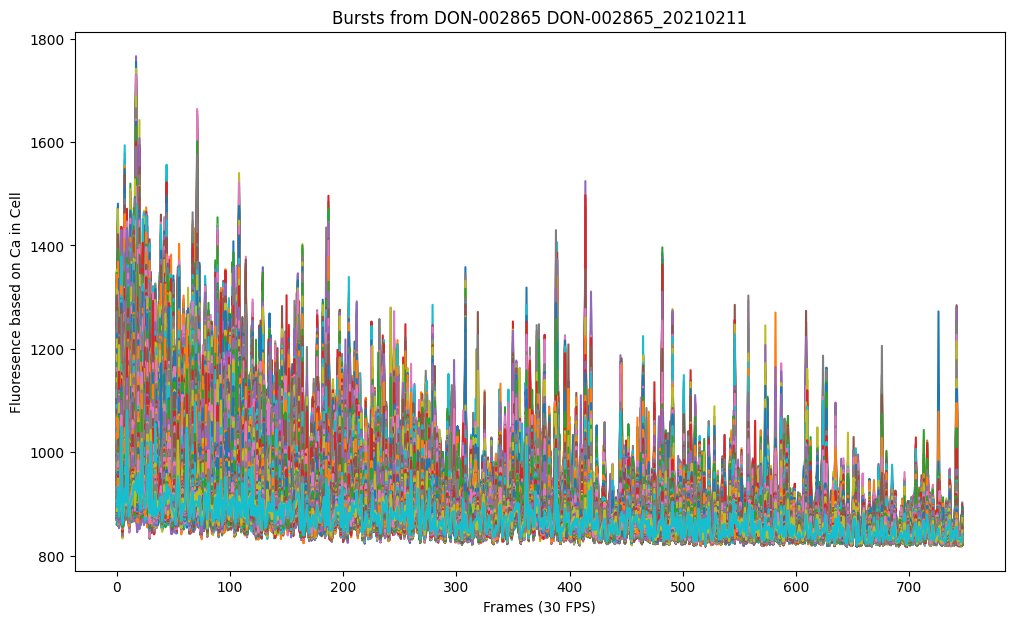

<Figure size 640x480 with 0 Axes>

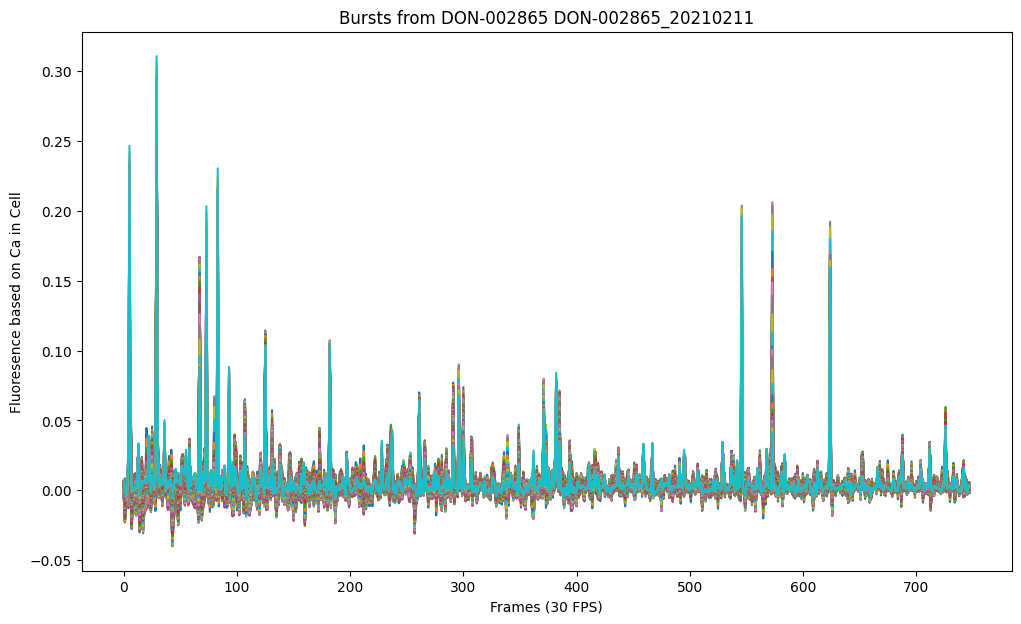

In [10]:
#plot bursts and get Fluoresence
F = viz.bursts(animal_id, session, num_cells="all")
F = viz.bursts(animal_id, session, fluoresence_type="filtered", num_cells=100)

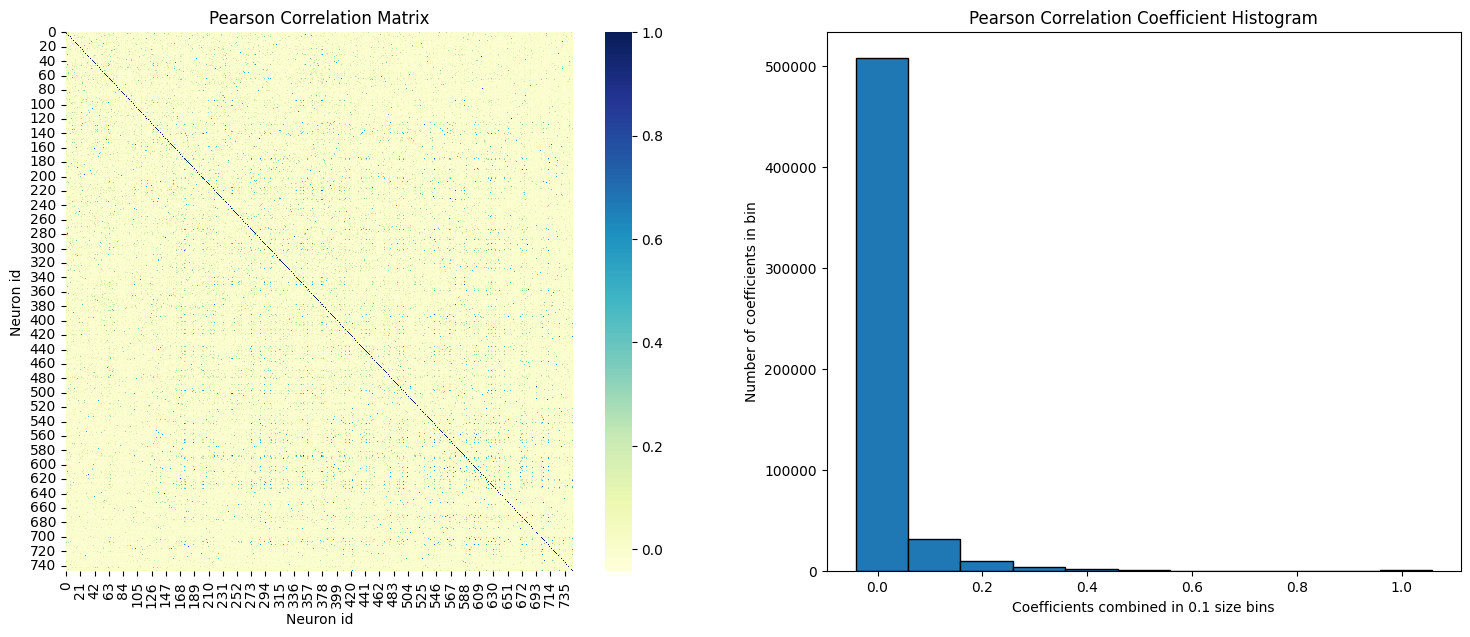

In [11]:
#plot pearon coefficients and histogram and get correlation data
corr_matrix, pval_matrix = viz.pearson_hist(animal_id, session, title=f"Pearson_{animal_id}_{session}.png")

### Multiple animals

In [12]:
#Load all animals
animals = load_all(root_dir) # Load all animals
#animals = load_all(root_dir, ["DON-002865"]) # Load specific animals
#Get overview of all sessions of an animal
df = animals["DON-002865"].get_overview()
df

name: DON-002865

Loading animal: DON-002865
Loading session: DON-002865 DON-002865_20210210
Finished DON-002865: DON-002865_20210210
Loading session: DON-002865 DON-002865_20210211
Finished DON-002865: DON-002865_20210211
Loading session: DON-002865 DON-002865_202102112
Finished DON-002865: DON-002865_202102112
Loading session: DON-002865 DON-002865_202102113
Finished DON-002865: DON-002865_202102113
Loading session: DON-002865 DON-002865_202102114
Finished DON-002865: DON-002865_202102114
Loading session: DON-002865 DON-002865_202102115
Finished DON-002865: DON-002865_202102115
Loading session: DON-002865 DON-002865_202102116
Finished DON-002865: DON-002865_202102116
Loading session: DON-002865 DON-002865_202102117
Finished DON-002865: DON-002865_202102117
Loading session: DON-002865 DON-002865_202102118
Finished DON-002865: DON-002865_202102118
Loading session: DON-002865 DON-002865_202102119
Finished DON-002865: DON-002865_202102119
name: DON-003165

Loading animal: DON-003165
Load

,session_name,date,P,suite2p_folder_paths
0,DON-002865_20210210,20210210,90,[D:\Rodrigo\DON-002865\DON-002865_20210210\002...
1,DON-002865_20210211,20210211,91,[D:\Rodrigo\DON-002865\DON-002865_20210211\002...
2,DON-002865_202102112,20210212,92,[D:\Rodrigo\DON-002865\DON-002865_202102112\00...
3,DON-002865_202102113,20210213,93,[D:\Rodrigo\DON-002865\DON-002865_202102113\00...
4,DON-002865_202102114,20210214,94,[D:\Rodrigo\DON-002865\DON-002865_202102114\00...
5,DON-002865_202102115,20210215,95,[D:\Rodrigo\DON-002865\DON-002865_202102115\00...
6,DON-002865_202102116,20210216,96,[D:\Rodrigo\DON-002865\DON-002865_202102116\00...
7,DON-002865_202102117,20210217,97,[D:\Rodrigo\DON-002865\DON-002865_202102117\00...
8,DON-002865_202102118,20210218,98,[D:\Rodrigo\DON-002865\DON-002865_202102118\00...
9,DON-002865_202102119,20210219,99,[D:\Rodrigo\DON-002865\DON-002865_202102119\00...


In [40]:
# Delete old and Create new Vizualizer 
try:
    del viz
except:
    pass
viz = Vizualizer(animals)

In [30]:
# Filter for animals possible for animal_id, year or sex, as well as combinations 
filtered_animals = filter_animals(animals, filters=["DON-002865"]) # [2021, "male"]

# print filtered animals
for id, animal in filtered_animals.items():
    print(f"{id} {animal.sex}")

# print unfiltered animals
print("---------------------------------")
for id, animal in animals.items():
    print(f"{id} {animal.sex}")

DON-002865 male
---------------------------------
DON-002865 male
DON-003165 male
DON-003343 male
DON-006084 male
DON-006085 male
DON-006087 male


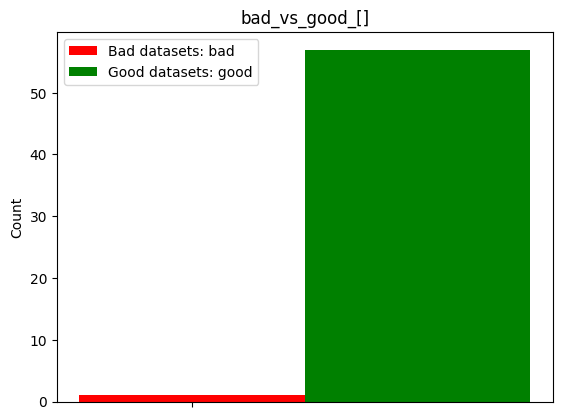

In [31]:
# Plot good bad dataset count
viz.plot_good_bad(filters=[])

<Figure size 640x480 with 0 Axes>

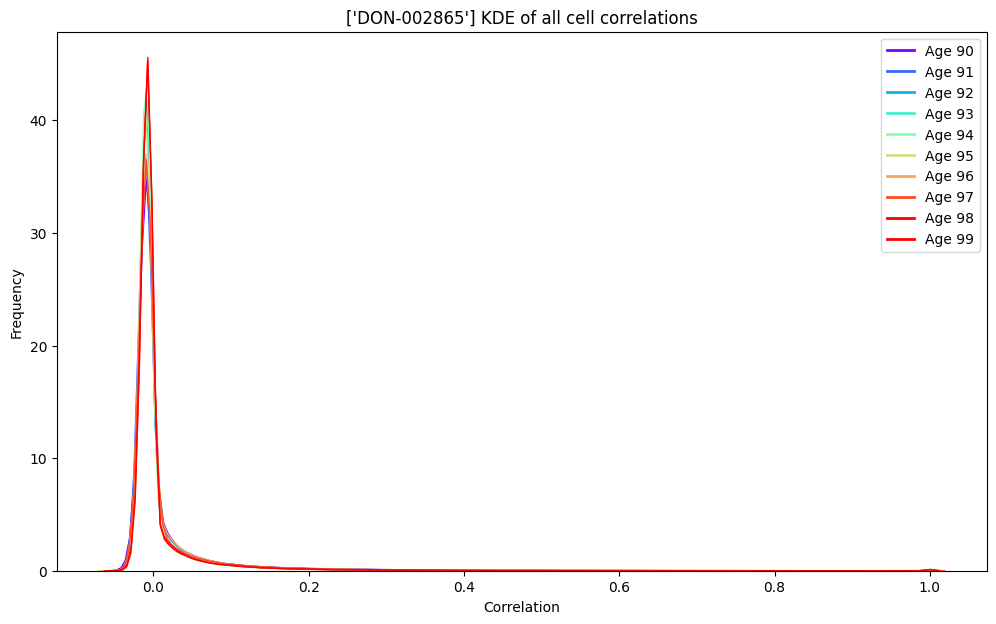

<Figure size 640x480 with 0 Axes>

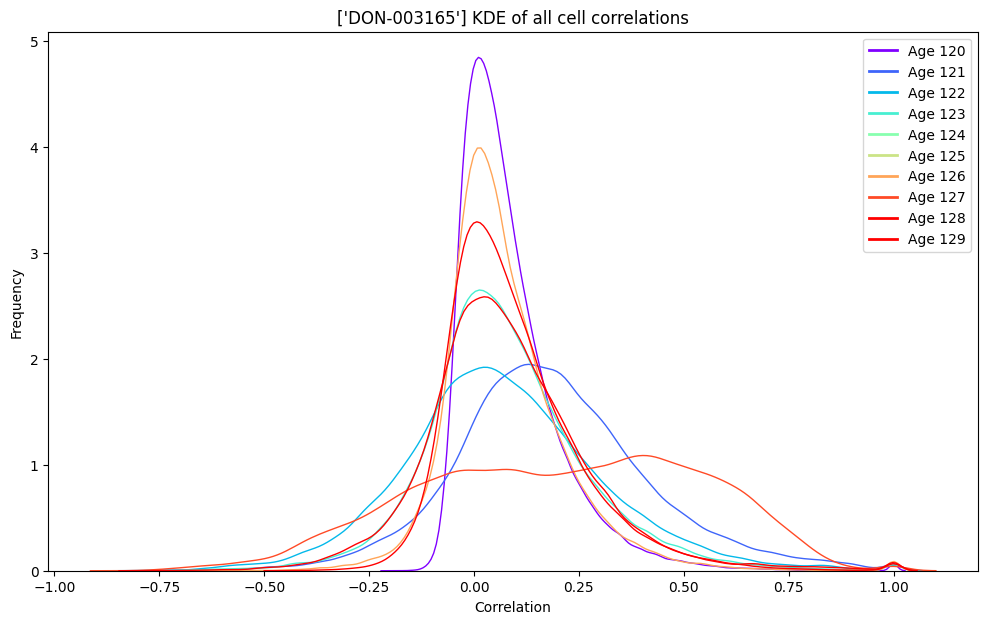

<Figure size 640x480 with 0 Axes>

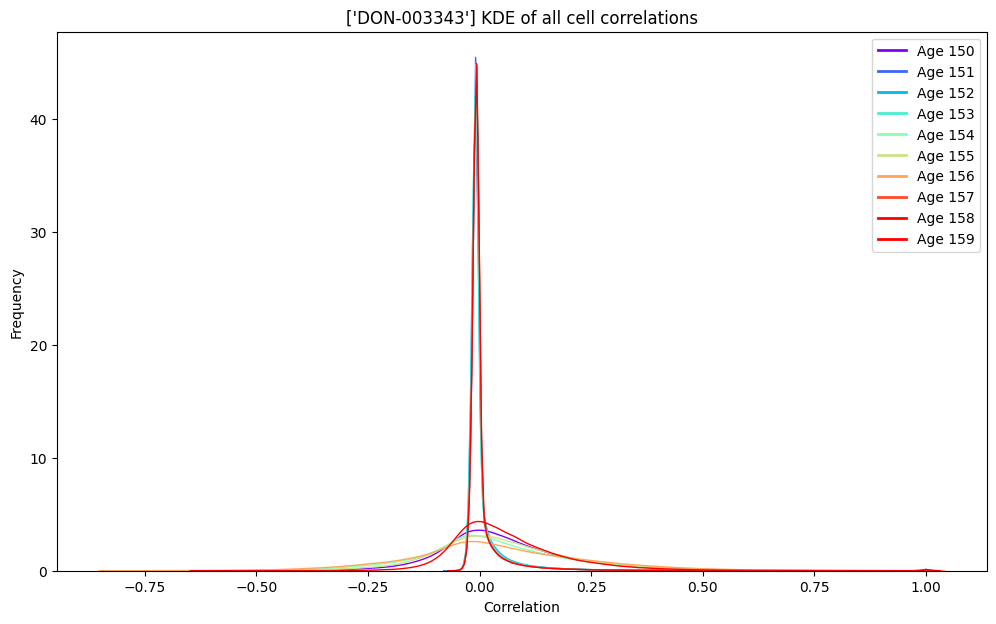

<Figure size 640x480 with 0 Axes>

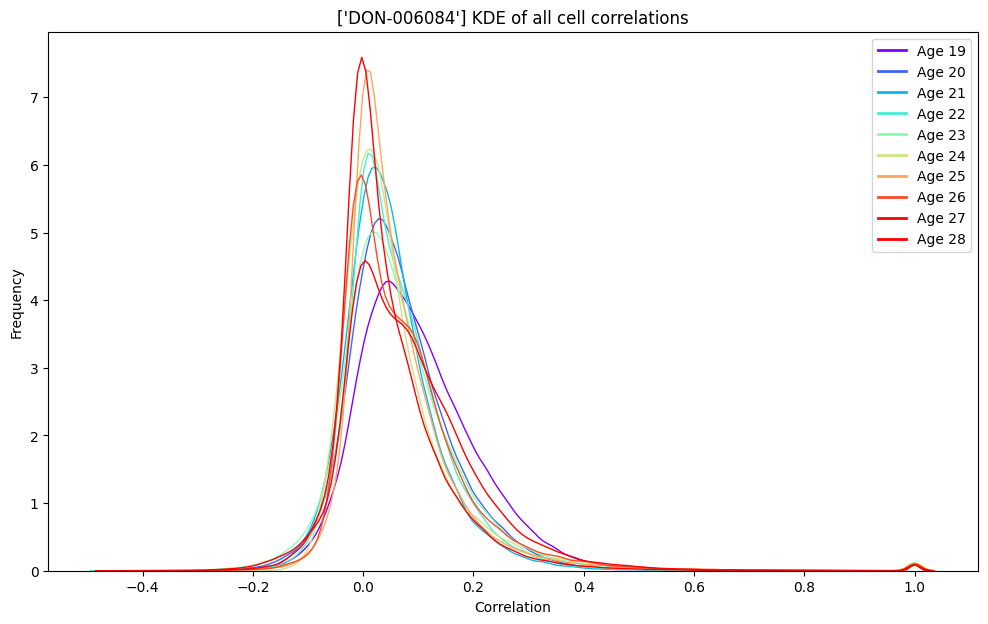

<Figure size 640x480 with 0 Axes>

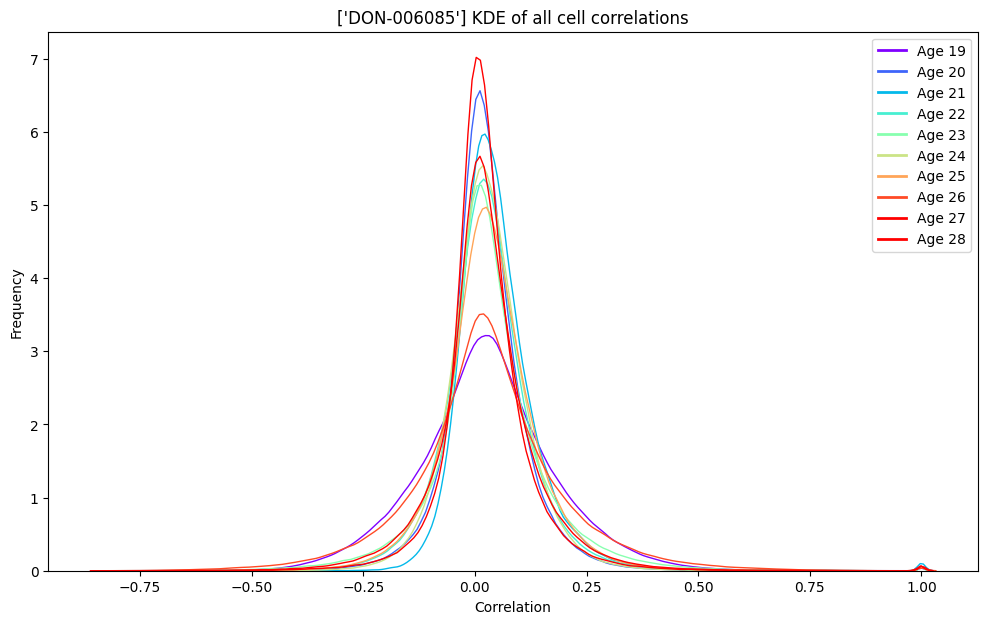

<Figure size 640x480 with 0 Axes>

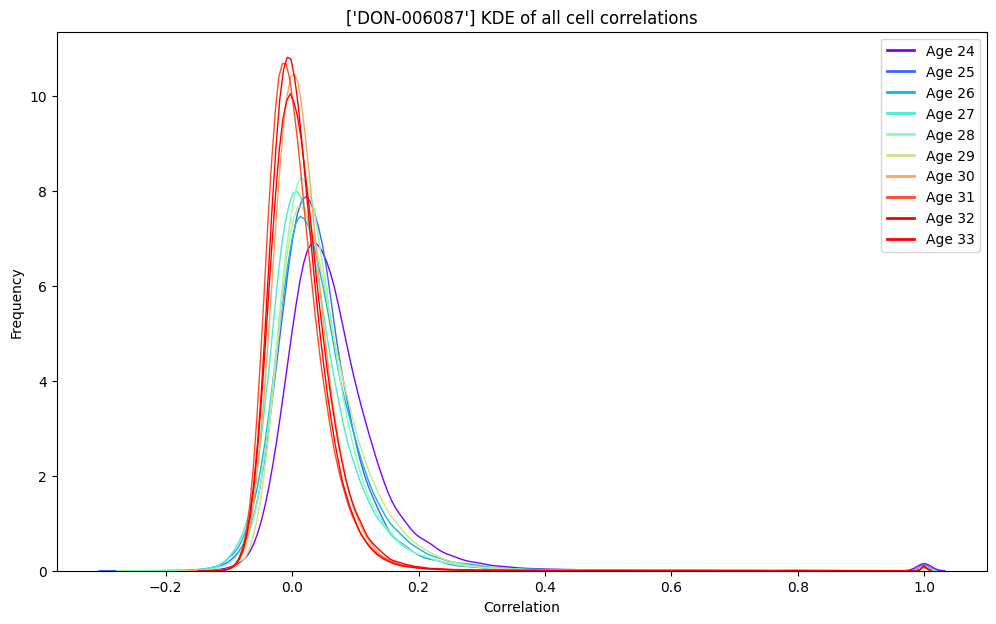

In [32]:
# Create Kernel Density Estimation for every Mouse or year
for animal_id in list(animals.keys()):
    viz.pearson_kde(filters=[animal_id]) #filters=["DON-002865"]) # [2021, "male"]

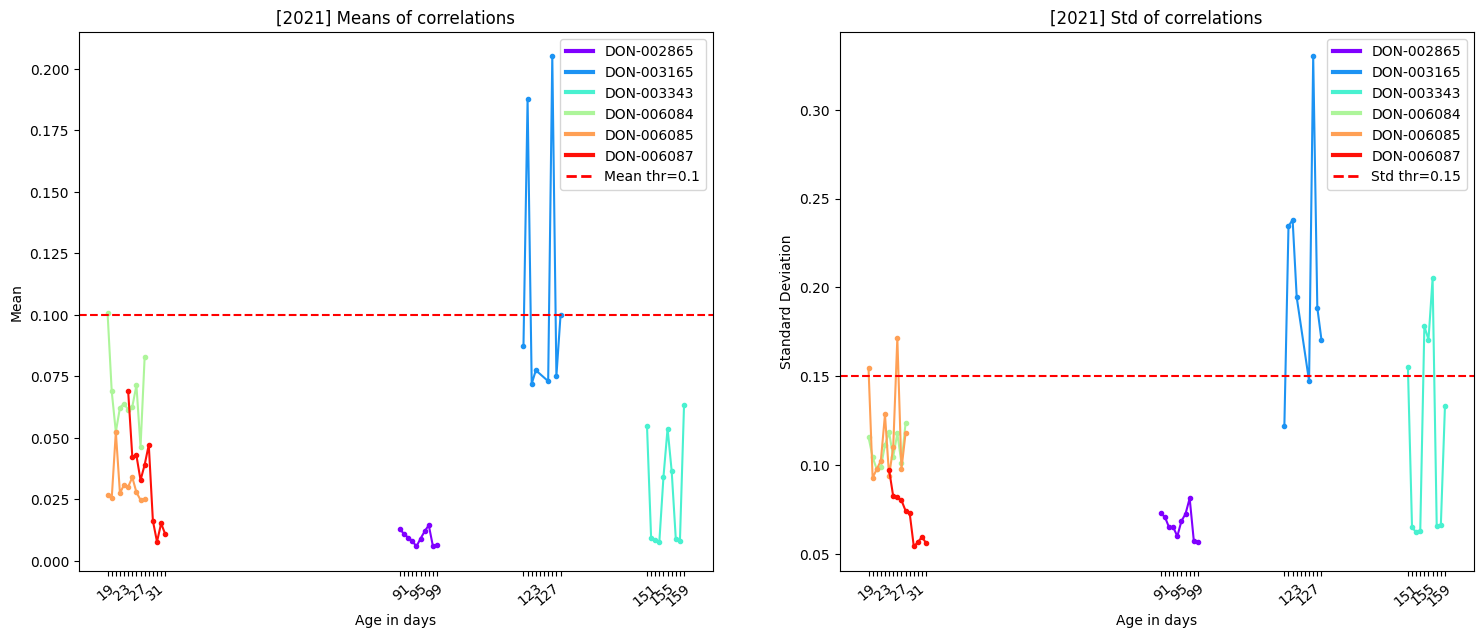

In [41]:
# Plot Lines for mean and standard deviation of correlation coefficients
viz.plot_means_stds(filters=[2021])